In [1]:
import pandas as pd 
import numpy as np
import sqlite3
import logging
import joblib
import matplotlib.pyplot as plt 

from pathlib import Path
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score 

In [2]:

log_file = Path(r"c:\Users\scarl\Desktop\Eng-dados\data\logs\projeto.log")
log_file.parent.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename=str(log_file),
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True,
)

In [3]:
try:
    # Load the dataset
    df = pd.read_csv("../data/case_inadimplencia_dataset.csv")
    logging.info("CSV carregado.")
except Exception as erro:
    logging.error(erro)
    print(erro)

[Errno 2] No such file or directory: '../data/case_inadimplencia_dataset.csv'


In [4]:
import pandas as pd


df = pd.read_csv("../case_inadimplencia_dataset.csv")
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_cliente                  5000 non-null   object 
 1   data_contratacao            5000 non-null   object 
 2   idade                       5000 non-null   int64  
 3   sexo                        5000 non-null   object 
 4   regiao                      5000 non-null   object 
 5   renda_mensal                5000 non-null   int64  
 6   classe_social               5000 non-null   object 
 7   score_interno               5000 non-null   int64  
 8   canal_aquisicao             5000 non-null   object 
 9   num_emprestimos_anteriores  5000 non-null   int64  
 10  tempo_relacionamento_dias   5000 non-null   int64  
 11  possui_restricao            5000 non-null   int64  
 12  valor_solicitado            5000 non-null   int64  
 13  prazo_meses                 5000 

id_cliente                    0
data_contratacao              0
idade                         0
sexo                          0
regiao                        0
renda_mensal                  0
classe_social                 0
score_interno                 0
canal_aquisicao               0
num_emprestimos_anteriores    0
tempo_relacionamento_dias     0
possui_restricao              0
valor_solicitado              0
prazo_meses                   0
taxa_juros_am                 0
valor_parcela                 0
comprometimento_renda         0
finalidade                    0
dias_atraso_max               0
inadimplente_90d              0
dtype: int64

In [5]:
df = df.drop_duplicates()
df = df.dropna()

logging.info("Dados limpos.")

In [6]:
df["inadimplente_90d"] = df["valor_solicitado"] + df["prazo_meses"]

In [7]:
from pathlib import Path
from sqlalchemy import create_engine

db_path = Path(r"c:\Users\scarl\Desktop\Eng-dados\data\database\projeto.db")
db_path.parent.mkdir(parents=True, exist_ok=True)

engine = create_engine(f"sqlite:///{db_path.as_posix()}")

In [8]:
from pathlib import Path
import sqlite3
import pandas as pd

db_path = Path(r"c:\Users\scarl\Desktop\Eng-dados\data\database\projeto.db")
conexao = sqlite3.connect(db_path)

tabelas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conexao)
print(tabelas)


Empty DataFrame
Columns: [name]
Index: []


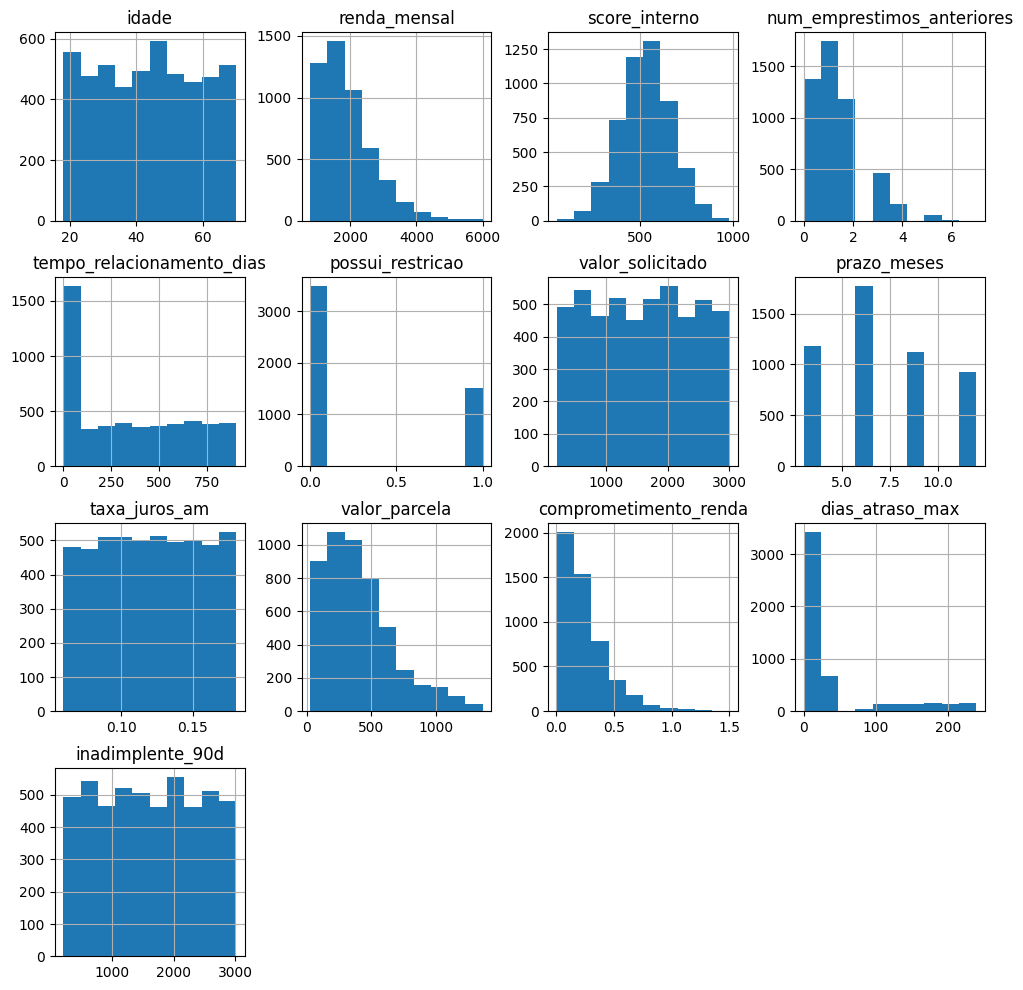

In [9]:
df.hist(figsize=(12,12))

plt.show()

In [10]:
X = df.drop(columns=["inadimplente_90d"])

y = df["inadimplente_90d"]

X = pd.get_dummies(X)

In [11]:
X_train, X_test, y_train, y_test =train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

modelo =RandomForestClassifier(
    random_state=42,
)

modelo.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [12]:
predicoes = modelo.predict(
    X_test
)

print(
    accuracy_score(
        y_test,
        predicoes
    )
)

0.239


In [13]:
from pathlib import Path

model_path = Path(r"C:\Users\scarl\Desktop\Eng-dados\data\models\modelo.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo, model_path)

['C:\\Users\\scarl\\Desktop\\Eng-dados\\data\\models\\modelo.pkl']

##
PORTUGUÊS:

Neste projeto foi desenvolvido uma pipeline completo em engenharia de dados utilizando Python e SQL.

O fluxo contemplou:

- Leitura dos dados
- Limpeza
- Validação da qualidade
- Criação de novas variáveis
- Persistência em banco SQLite
- Consultas SQL
- Visualização gráfica
- Treinamento de Machine Learning
- Salvamento do modelo
- Registro de logs


##
ENGLISH:

That's project was developing a complete Data Engineer pipeline using Python and SQL.

The workflow included: 

- Data ingestion
- Cleaning
- Quality validation
- Feature engineering
- Persistence in an SQLite database
- SQL queries
- Data visualization
- Machine learning training
- Model saving
- Logging